✅ Model loaded successfully!
Found 130 validation images


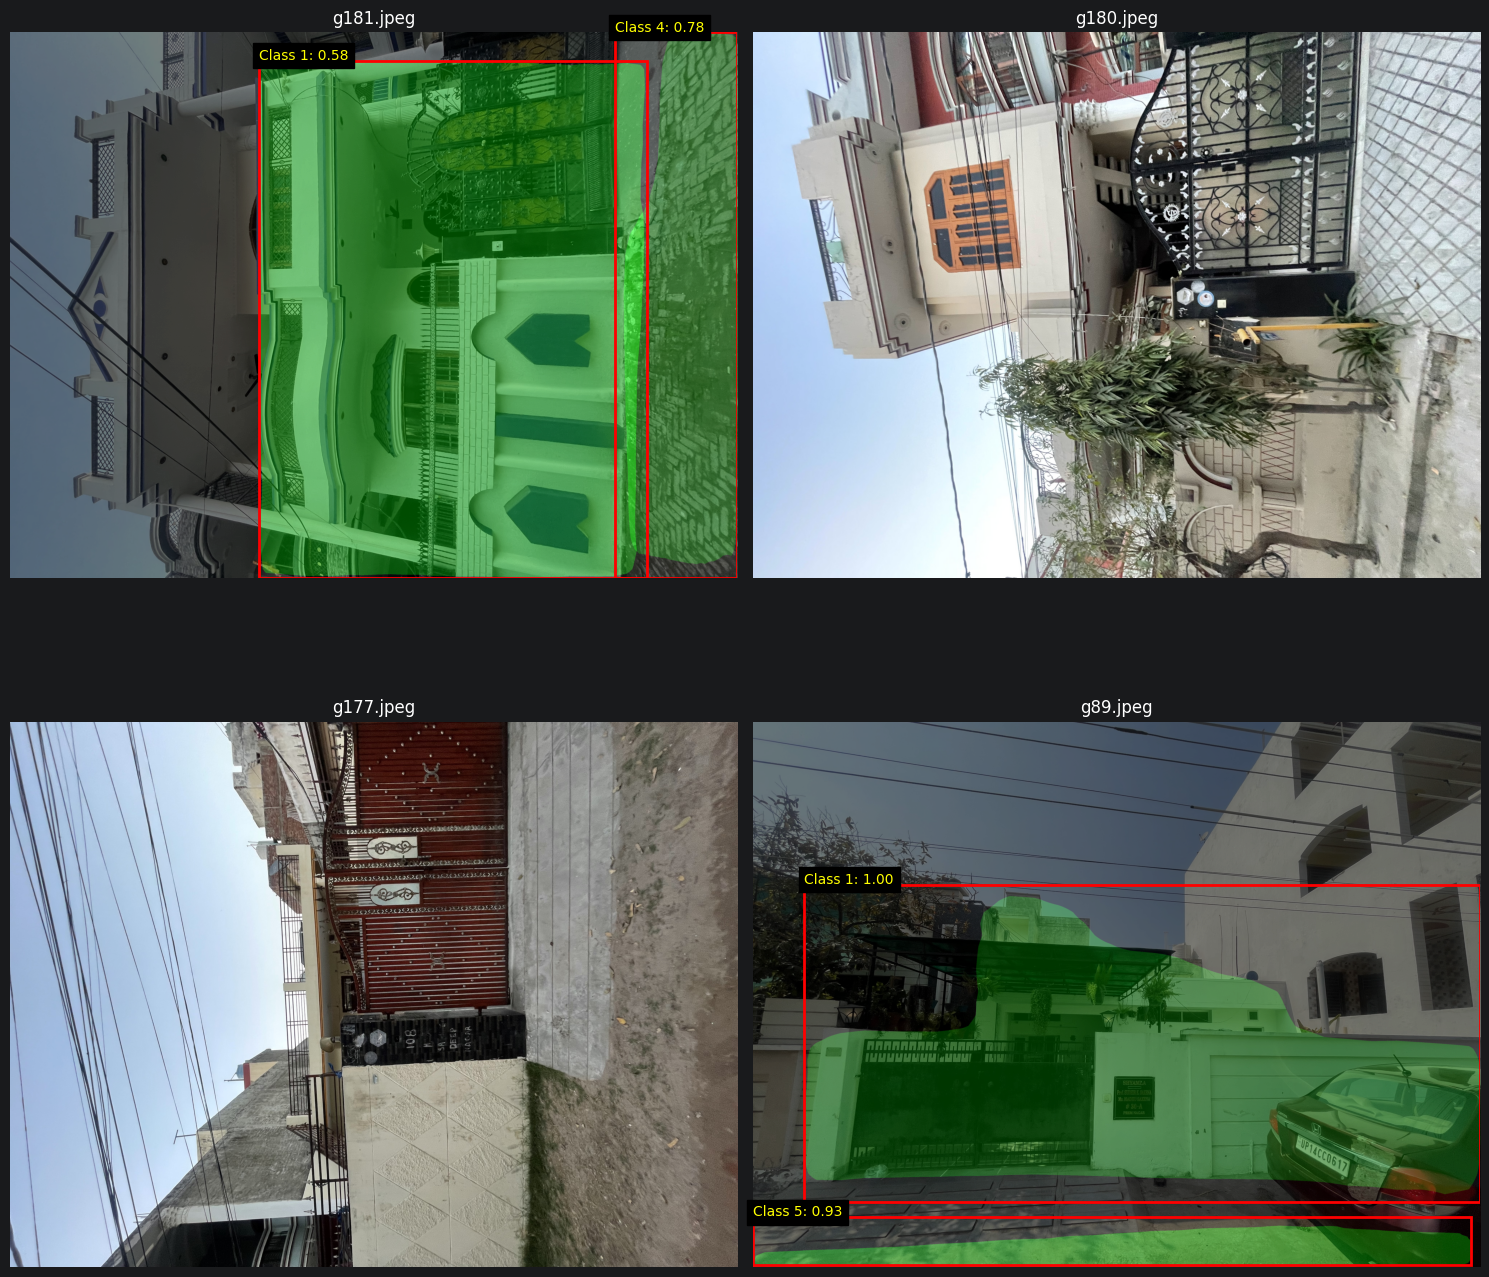

In [1]:
import os
import random
import torch
import torchvision
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.transforms import functional as F
import matplotlib.patches as patches
import numpy as np

# ==========================================
# CONFIG
# ==========================================
MODEL_PATH = "mask_rcnn_model.pth"

VAL_IMAGE_DIR = "val_anu"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# LOAD MODEL
# ==========================================
num_classes = 7   # CHANGE THIS if you have more classes

model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights=None)

in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_features,
    num_classes
)

in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels

hidden_layer = 256

model.roi_heads.mask_predictor = torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(
    in_features_mask,
    hidden_layer,
    num_classes
)

# ==========================================
# LOAD TRAINED WEIGHTS
# ==========================================
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))

model.to(DEVICE)
model.eval()

print("✅ Model loaded successfully!")

# ==========================================
# GET VALIDATION IMAGES
# ==========================================
image_files = [
    f for f in os.listdir(VAL_IMAGE_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print(f"Found {len(image_files)} validation images")

# ==========================================
# RANDOM SAMPLE
# ==========================================
sample_images = random.sample(image_files, min(4, len(image_files)))

# ==========================================
# INFERENCE
# ==========================================
plt.figure(figsize=(15, 15))

for idx, image_name in enumerate(sample_images):

    image_path = os.path.join(VAL_IMAGE_DIR, image_name)

    image = Image.open(image_path).convert("RGB")

    image_tensor = F.to_tensor(image).to(DEVICE)

    with torch.no_grad():
        prediction = model([image_tensor])[0]

    # Convert image for plotting
    image_np = np.array(image)

    ax = plt.subplot(2, 2, idx + 1)
    ax.imshow(image_np)

    boxes = prediction["boxes"].cpu().numpy()
    scores = prediction["scores"].cpu().numpy()
    labels = prediction["labels"].cpu().numpy()

    # Masks
    masks = prediction["masks"].cpu().numpy()

    # ==========================================
    # DRAW PREDICTIONS
    # ==========================================
    for box, score, label, mask in zip(boxes, scores, labels, masks):

        # Confidence threshold
        if score < 0.5:
            continue

        x1, y1, x2, y2 = box

        # Draw box
        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )

        ax.add_patch(rect)

        # Draw label
        ax.text(
            x1,
            y1 - 5,
            f"Class {label}: {score:.2f}",
            color='yellow',
            fontsize=10,
            backgroundcolor='black'
        )

        # Draw mask
        mask = mask[0]

        mask_binary = mask > 0.5

        colored_mask = np.zeros_like(image_np)
        colored_mask[:, :, 1] = mask_binary * 255

        ax.imshow(colored_mask, alpha=0.3)

    ax.set_title(image_name)
    ax.axis("off")

plt.tight_layout()
plt.show()